# Cereal

## Initation

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline
# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [70]:
dataset=pd.read_csv('Cereals_Dataset_63_1.csv')
dataset.head()

,Cereals,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,rating,Unnamed: 12,Unnamed: 13
0,100%_Bran,70,4,1,130,10.0,5.0,6,280.0,25,3,68.402973,NaN,1. 1st column : Name of cereal
1,100%_Natural_Bran,120,3,5,15,2.0,8.0,8,135.0,0,3,33.983679,NaN,2. calories: calories per serving
2,All-Bran,70,4,1,260,9.0,7.0,5,320.0,25,3,59.425505,NaN,3. protein: grams of protein
3,All-Bran_with_Extra_Fiber,50,4,0,140,14.0,8.0,0,330.0,25,3,93.704912,NaN,4. fat: grams of fat
4,Almond_Delight,110,2,2,200,1.0,14.0,8,NaN,25,3,34.384843,NaN,5. sodium: milligrams of sodium


In [71]:
dataset = dataset.drop(columns=['Unnamed: 12','Unnamed: 13'], errors='ignore')
dataset

,Cereals,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,rating
0,100%_Bran,70,4,1,130,10.0,5.0,6,280.0,25,3,68.402973
1,100%_Natural_Bran,120,3,5,15,2.0,8.0,8,135.0,0,3,33.983679
2,All-Bran,70,4,1,260,9.0,7.0,5,320.0,25,3,59.425505
3,All-Bran_with_Extra_Fiber,50,4,0,140,14.0,8.0,0,330.0,25,3,93.704912
4,Almond_Delight,110,2,2,200,1.0,14.0,8,NaN,25,3,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,110,2,1,250,0.0,21.0,3,60.0,25,3,39.106174
73,Trix,110,1,1,140,0.0,13.0,12,25.0,25,2,27.753301
74,Wheat_Chex,100,3,1,230,3.0,17.0,3,115.0,25,1,49.787445
75,Wheaties,100,3,1,200,3.0,17.0,3,110.0,25,1,51.592193


## Clean data

In [72]:
dataset_cleaned = dataset.copy()
dataset_cleaned = dataset_cleaned.dropna()
categorical_columns = dataset.select_dtypes(include=['object']).columns
numerical_columns = dataset.select_dtypes(exclude=['object']).columns

# ถ้าแก้หมดต้องไม่มีอะไรออกมา
for i in categorical_columns:
    missing_percent = (dataset_cleaned[i].isnull().sum() / len(dataset))
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.4f}% missing values")

for i in numerical_columns:
    missing_percent = (dataset_cleaned[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

<Axes: >

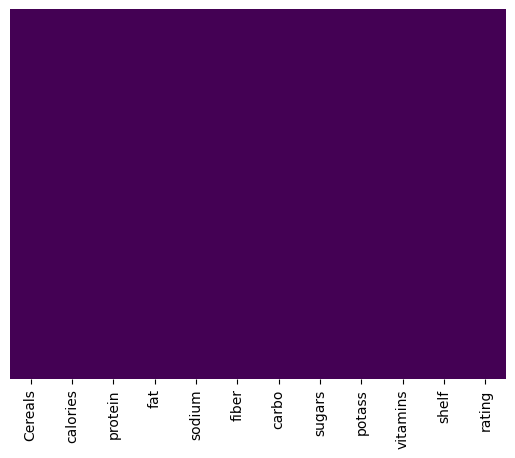

In [73]:
sns.heatmap(dataset_cleaned.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [74]:
dataset_cleaned

,Cereals,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,rating
0,100%_Bran,70,4,1,130,10.0,5.0,6,280.0,25,3,68.402973
1,100%_Natural_Bran,120,3,5,15,2.0,8.0,8,135.0,0,3,33.983679
2,All-Bran,70,4,1,260,9.0,7.0,5,320.0,25,3,59.425505
3,All-Bran_with_Extra_Fiber,50,4,0,140,14.0,8.0,0,330.0,25,3,93.704912
5,Apple_Cinnamon_Cheerios,110,2,2,180,1.5,10.5,10,70.0,25,1,29.509541
...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,110,2,1,250,0.0,21.0,3,60.0,25,3,39.106174
73,Trix,110,1,1,140,0.0,13.0,12,25.0,25,2,27.753301
74,Wheat_Chex,100,3,1,230,3.0,17.0,3,115.0,25,1,49.787445
75,Wheaties,100,3,1,200,3.0,17.0,3,110.0,25,1,51.592193


## Min-max normalization

In [75]:
data_nomalize = dataset_cleaned.copy()

In [76]:
columns_to_normalize = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins']

scaler = MinMaxScaler()
data_nomalize[columns_to_normalize] = scaler.fit_transform(data_nomalize[columns_to_normalize])
data_nomalize

,Cereals,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,rating
0,100%_Bran,0.181818,0.6,0.2,0.406250,0.714286,0.250000,0.4375,0.841270,0.25,3,68.402973
1,100%_Natural_Bran,0.636364,0.4,1.0,0.046875,0.142857,0.375000,0.5625,0.380952,0.00,3,33.983679
2,All-Bran,0.181818,0.6,0.2,0.812500,0.642857,0.333333,0.3750,0.968254,0.25,3,59.425505
3,All-Bran_with_Extra_Fiber,0.000000,0.6,0.0,0.437500,1.000000,0.375000,0.0625,1.000000,0.25,3,93.704912
5,Apple_Cinnamon_Cheerios,0.545455,0.2,0.4,0.562500,0.107143,0.479167,0.6875,0.174603,0.25,1,29.509541
...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,0.545455,0.2,0.2,0.781250,0.000000,0.916667,0.2500,0.142857,0.25,3,39.106174
73,Trix,0.545455,0.0,0.2,0.437500,0.000000,0.583333,0.8125,0.031746,0.25,2,27.753301
74,Wheat_Chex,0.454545,0.4,0.2,0.718750,0.214286,0.750000,0.2500,0.317460,0.25,1,49.787445
75,Wheaties,0.454545,0.4,0.2,0.625000,0.214286,0.750000,0.2500,0.301587,0.25,1,51.592193


In [77]:
nutrient = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'rating']
nutrient_sum = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins']

data_nomalize['nutrient_score'] = data_nomalize[nutrient_sum].sum(axis=1)
data_nomalize

,Cereals,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,rating,nutrient_score
0,100%_Bran,0.181818,0.6,0.2,0.406250,0.714286,0.250000,0.4375,0.841270,0.25,3,68.402973,3.881124
1,100%_Natural_Bran,0.636364,0.4,1.0,0.046875,0.142857,0.375000,0.5625,0.380952,0.00,3,33.983679,3.544548
2,All-Bran,0.181818,0.6,0.2,0.812500,0.642857,0.333333,0.3750,0.968254,0.25,3,59.425505,4.363763
3,All-Bran_with_Extra_Fiber,0.000000,0.6,0.0,0.437500,1.000000,0.375000,0.0625,1.000000,0.25,3,93.704912,3.725000
5,Apple_Cinnamon_Cheerios,0.545455,0.2,0.4,0.562500,0.107143,0.479167,0.6875,0.174603,0.25,1,29.509541,3.406367
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,0.545455,0.2,0.2,0.781250,0.000000,0.916667,0.2500,0.142857,0.25,3,39.106174,3.286228
73,Trix,0.545455,0.0,0.2,0.437500,0.000000,0.583333,0.8125,0.031746,0.25,2,27.753301,2.860534
74,Wheat_Chex,0.454545,0.4,0.2,0.718750,0.214286,0.750000,0.2500,0.317460,0.25,1,49.787445,3.555041
75,Wheaties,0.454545,0.4,0.2,0.625000,0.214286,0.750000,0.2500,0.301587,0.25,1,51.592193,3.445418


In [78]:
df_scaled = scaler.fit_transform(data_nomalize.drop('Cereals', axis=1))

## Stage for k-mean clustering

In [79]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [80]:
wcss = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df_scaled)
    wcss.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

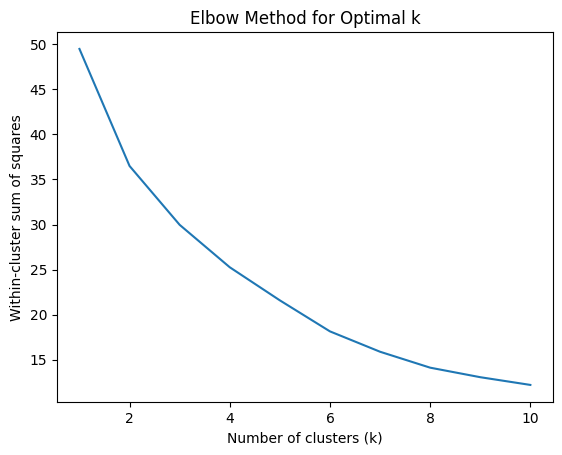

In [81]:
# Plot the Elbow Method graph
plt.plot(k_rng, wcss)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares')
plt.title('Elbow Method for Optimal k')
plt.show()

## By sum of nutrient. (Every ingridients)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


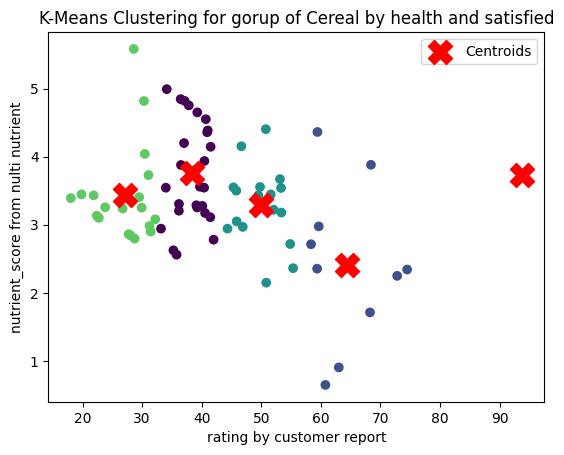

Inertia: 1076.462808228461


In [82]:
# Preprocessing data
X = data_nomalize[['rating', 'nutrient_score']]

kmeans = KMeans(n_clusters=5, random_state=42)
data_nomalize['Cluster'] = kmeans.fit_predict(X)

# Visualizing the clusters
plt.scatter(data_nomalize['rating'], data_nomalize['nutrient_score'], c=data_nomalize['Cluster'], cmap='viridis')
plt.title('K-Means Clustering for gorup of Cereal by health and satisfied')
plt.xlabel('rating by customer report')
plt.ylabel('nutrient_score from nulti nutrient')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.legend()
plt.show()

inertia = kmeans.inertia_

print("Inertia:", inertia)

In [83]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_use = data_nomalize[['rating', 'nutrient_score']]

df = pd.DataFrame(data_use)

# Specify the number of clusters (k)
k = 5

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster_num'] = kmeans.fit_predict(data_nomalize[['rating', 'nutrient_score']])

# Display the DataFrame with the new 'cluster_num' column
df

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,rating,nutrient_score,cluster_num
0,68.402973,3.881124,1
1,33.983679,3.544548,0
2,59.425505,4.363763,1
3,93.704912,3.725000,4
5,29.509541,3.406367,3
...,...,...,...
72,39.106174,3.286228,0
73,27.753301,2.860534,3
74,49.787445,3.555041,2
75,51.592193,3.445418,2


### sugary cereals

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


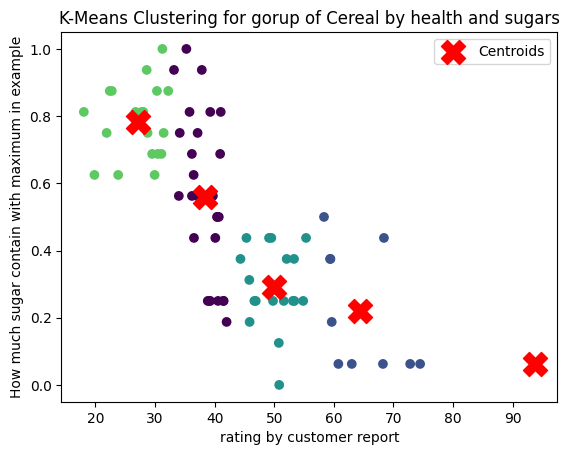

Inertia: 1038.3696231270378


In [84]:
# Preprocessing data
X = data_nomalize[['rating', 'sugars']]

kmeans = KMeans(n_clusters=5, random_state=42)
data_nomalize['Cluster'] = kmeans.fit_predict(X)

# Visualizing the clusters
plt.scatter(data_nomalize['rating'], data_nomalize['sugars'], c=data_nomalize['Cluster'], cmap='viridis')
plt.title('K-Means Clustering for gorup of Cereal by health and sugars')
plt.xlabel('rating by customer report')
plt.ylabel('How much sugar contain with maximum in example')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.legend()
plt.show()

inertia = kmeans.inertia_

print("Inertia:", inertia)

In [85]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_use = data_nomalize[['rating', 'sugars']]

df = pd.DataFrame(data_use)

# Specify the number of clusters (k)
k = 5

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster_num'] = kmeans.fit_predict(data_nomalize[['rating', 'sugars']])

# Display the DataFrame with the new 'cluster_num' column
df

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,rating,sugars,cluster_num
0,68.402973,0.4375,1
1,33.983679,0.5625,0
2,59.425505,0.3750,1
3,93.704912,0.0625,4
5,29.509541,0.6875,3
...,...,...,...
72,39.106174,0.2500,0
73,27.753301,0.8125,3
74,49.787445,0.2500,2
75,51.592193,0.2500,2
